#### This is the script for testing/prediction, the input files will be dyad audios and will output parallel/identical TextGrid for each audio file with annotations of turn-taking transitions. Here are some key points of this script.

##### The pre-trained model (already loaded as loaded_model) is used to decode the combined features into a frame-level prediction. Integer predictions are mapped to their string labels via an id2label mapping.

##### When the prediction is done, they want both textgrid files to be exported. The input to the model comes from combined features of two audio files, and after decoding, we need to convert that sequence to a textgrid. Our custom CRF model outputs the same predicted sequence for both channels. The output textgrid should follow the file naming rules, with an additional "_Predicted" suffix.

##### Smoothing: Merge consecutive speech frames into longer segments to avoid overly fragmented annotations.

##### Boundary Adjustment: You might also adjust the segment boundaries slightly to capture the full onset and offset of speech.

###### *[Author]* `Moana Chen`
###### *[Date]* `30.03.2025`

##### Load pre-trained model

In [ ]:
# #!pip uninstall -y praatio
# !pip install 'praatio<5'
# !pip install soundfile
# !pip install librosa
# !pip install pytorch-crf
# !pip install seaborn

  Using cached pandas-2.2.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 6.0 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.2 

In [1]:
# # mount google drive

# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
import glob
import numpy as np
import torch
import soundfile as sf
import librosa
from praatio import tgio
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

In [3]:
label2id = {"TURN": 0, "<G>": 1, "<B>": 2, "<O>": 3}
id2label = {v: k for k, v in label2id.items()}

In [5]:
import torch.nn as nn
from torchcrf import CRF

class BiLSTMCRFModel(nn.Module): ## model archi load
    def __init__(self, input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, n_labels)
        self.crf = CRF(n_labels, batch_first=True)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout(lstm_out)
        logits = self.classifier(lstm_out) 
        return logits

    def compute_loss(self, logits, tags, mask=None):
        return -self.crf(logits, tags, mask=mask, reduction='mean')

    def decode(self, logits, mask=None):
        return self.crf.decode(logits, mask=mask)

def smooth_label_sequence(labels, window_size=16):
    """
    Simple smoothing via majority vote in a sliding window.
    """
    if window_size % 2 == 0:
        window_size += 1
    half_window = window_size // 2
    n = len(labels)
    smoothed = []
    for i in range(n):
        window = labels[max(0, i - half_window): min(n, i + half_window + 1)]
        # majority vote
        smoothed.append(max(set(window), key=window.count))
    return smoothed

def merge_segments(labels, frame_duration=0.1):
    segments = []
    if not labels:
        return segments
    current_label = labels[0]
    start_frame = 0
    for i, label in enumerate(labels[1:], start=1):
        if label != current_label:
            start_time = float(start_frame * frame_duration)
            end_time = float(i * frame_duration)
            segments.append((start_time, end_time, current_label))
            current_label = label
            start_frame = i
    segments.append((float(start_frame * frame_duration), float(len(labels) * frame_duration), current_label))
    return segments

def create_textgrid_from_segments(segments, total_duration, tier_name="PredictedTransitions"): # create tier
    tg = tgio.Textgrid()
    tier = tgio.IntervalTier(tier_name, segments, 0.0, float(total_duration))
    # force the tier's minLength to be a float so that type comparisons work.
    tier.minLength = 0.0
    tg.addTier(tier)
    return tg


def get_output_textgrid_path(audio_path):
    return audio_path.replace(".wav", "_Predicted.TextGrid")

## feature extraction as we did in the training phase
def extract_mfcc(filepath, sr=44100, frame_duration=0.1, n_mfcc=13):
    audio_np, sample_rate = sf.read(filepath)
    if audio_np.ndim > 1:
        audio_np = np.mean(audio_np, axis=1)
    if sample_rate != sr:
        audio_np = librosa.resample(audio_np, orig_sr=sample_rate, target_sr=sr)
        sample_rate = sr

    hop_length = int(frame_duration * sr)
    mfcc = librosa.feature.mfcc(y=audio_np, sr=sample_rate, n_mfcc=n_mfcc,
                                n_fft=hop_length, hop_length=hop_length)
    return mfcc.T  # (num_frames, n_mfcc)

def create_label_sequence(textgrid_path, total_frames, frame_duration=0.1):
    """
    Generates a list of labels (strings) for each frame from a TextGrid file.
    We have a tier "transVals" with <G>, <B>, <O>, <L> (ignored), or no label.
    Returns a list of length total_frames, each element e.g. "None", "<G>", ...
    """
    try:
        tg = tgio.openTextgrid(textgrid_path)
    except Exception as e:
        print(f"Warning: Could not open {textgrid_path}: {e}")
        return ["TURN"] * total_frames

    if "transVals" not in tg.tierDict:
        return ["TURN"] * total_frames
    tier = tg.tierDict["transVals"]
    intervals = tier.entryList  # (start, end, label)

    labels = ["TURN"] * total_frames

    for (start, end, lab) in intervals:
        lab = lab.strip()
        if lab == "<L>":
            continue  # ignore laughter
        if lab in ["<G>", "<B>", "<O>"]:
            start_frame = int(start / frame_duration)
            end_frame = int(end / frame_duration) + 1
            for i in range(start_frame, min(end_frame, total_frames)):
                labels[i] = lab
    return labels

def combine_features(as_mfcc, is_mfcc):
    if as_mfcc.shape[0] != is_mfcc.shape[0]:
        min_frames = min(as_mfcc.shape[0], is_mfcc.shape[0])
        as_mfcc = as_mfcc[:min_frames]
        is_mfcc = is_mfcc[:min_frames]
    return np.concatenate([as_mfcc, is_mfcc], axis=1)


def combine_labels(as_labels, is_labels):
    merged = []
    for l_as, l_is in zip(as_labels, is_labels):
        if l_as != "TURN": # mark the empty [0] as TURN instead
            merged.append(l_as)
        elif l_is != "TURN":
            merged.append(l_is)
        else:
            merged.append("TURN")
    return merged


In [6]:
import torch.nn as nn
from torchcrf import CRF
# new model with ATTENTION.
class BiLSTMCRFModelWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4):
        """
        layers 1, dropout probability 0.1
        """
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim * 2,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Final classifier to produce logits for each time step.
        self.classifier = nn.Linear(hidden_dim * 2, n_labels)
        
        # CRF layer for structured prediction.
        self.crf = CRF(n_labels, batch_first=True)
    
    def forward(self, x, mask=None):
        lstm_out, _ = self.lstm(x)  # (B, T, 2*hidden_dim)
        lstm_out = self.dropout(lstm_out)
        
        if mask is not None:
            attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out, key_padding_mask=~mask)
            refined = lstm_out + attn_out
        else:
            refined = lstm_out
        
        logits = self.classifier(refined)  # (B, T, n_labels)
        return logits
    
    def compute_loss(self, logits, tags, mask=None):
        nll = -self.crf.forward(logits, tags, mask=mask, reduction="mean")
        return nll
    
    def decode(self, logits, mask=None):
        return self.crf.decode(logits, mask=mask)

The setup for prediction and TextGrid write

In [7]:
# 5) Inference on New Test Data
def predict_labels_for_pair(as_file, is_file, model, device, frame_duration=0.1, sr=44100, n_mfcc=13):
    # mfcc extraction
    as_m = extract_mfcc(as_file, sr=sr, frame_duration=frame_duration, n_mfcc=n_mfcc)
    is_m = extract_mfcc(is_file, sr=sr, frame_duration=frame_duration, n_mfcc=n_mfcc)

    combined = combine_features(as_m, is_m)  # (num_frames, 2*n_mfcc)
    print("Combined features shape:", combined.shape)

    if combined.shape[0] == 0:
        raise ValueError("No frames extracted from audio files. Check file paths and extraction parameters.")
    combined_tensor = torch.from_numpy(combined).unsqueeze(0).float().to(device)

    model.eval()
    with torch.no_grad():
        logits = model(combined_tensor)  # (1, num_frames, n_labels)
        best_paths = model.decode(logits) 
    predicted_ids = best_paths[0]

    print("Decoded label sequence (first 50 frames):", predicted_ids[:50])
    return predicted_ids, combined.shape[0]

def map_ids_to_labels(ids_list):
    return [id2label[i] for i in ids_list]

In [8]:
class GBOAudioDataset(Dataset):
    def __init__(self, base_dir, frame_duration=0.1, sr=44100, n_mfcc=13):
        """
        base_dir: path to a directory containing 'rec_*' subfolders.
        We assume each subfolder has matched AS/IS .wav files + .TextGrid.
        """
        super().__init__()
        self.samples = []  # will store tuples (feature_array, label_array)

        dyad_folders = glob.glob(os.path.join(base_dir, "rec_*"))
        for folder in dyad_folders:
            as_files = glob.glob(os.path.join(folder, "*_AS_*.wav"))
            is_files = glob.glob(os.path.join(folder, "*_IS_*.wav"))

            for as_file in as_files:
                # parse naming
                base_as = os.path.basename(as_file)
                parts = base_as.split("_")
                pair_num = parts[1]  # '***', etc.
                part_id = parts[-1].split(".")[0]  # '1' in rec_***_*S_id_***_*.wav
                # find matching IS
                matching_is = [f for f in is_files if f"rec_{pair_num}_IS_" in f and f"_{part_id}.wav" in f]
                if not matching_is:
                    continue
                is_file = matching_is[0]

                # corresponding TextGrid files
                as_textgrid = as_file.replace(".wav", ".TextGrid")
                is_textgrid = is_file.replace(".wav", ".TextGrid")

                # extract features from each speaker
                as_mfcc = extract_mfcc(as_file, sr=sr, frame_duration=frame_duration, n_mfcc=n_mfcc)
                is_mfcc = extract_mfcc(is_file, sr=sr, frame_duration=frame_duration, n_mfcc=n_mfcc)
                combined_feat = combine_features(as_mfcc, is_mfcc)  # shape: [num_frames, 2*n_mfcc]

                # merge
                total_frames = combined_feat.shape[0]
                labels_as = create_label_sequence(as_textgrid, total_frames, frame_duration)
                labels_is = create_label_sequence(is_textgrid, total_frames, frame_duration)
                merged_labels = combine_labels(labels_as, labels_is)

                # convert label to ID for prediction
                label_ids = [label2id.get(lab, 0) for lab in merged_labels]

                self.samples.append((combined_feat, label_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        features, label_ids = self.samples[idx]
        features_tensor = torch.from_numpy(features).float()  # [num_frames, 2*n_mfcc]
        labels_tensor = torch.tensor(label_ids, dtype=torch.long)  # [num_frames]
        return features_tensor, labels_tensor

In [12]:
def collate_fn(batch):
    max_len = max(features.shape[0] for (features, labels) in batch)
    feature_dim = batch[0][0].shape[1]  # from the first sample

    padded_features = []
    padded_labels = []
    masks = []

    for (features, labels) in batch:
        seq_len = features.shape[0]

        padded_f = torch.zeros(max_len, feature_dim, dtype=torch.float)
        padded_f[:seq_len, :] = features

        padded_l = torch.zeros(max_len, dtype=torch.long)
        padded_l[:seq_len] = labels

        mask = torch.zeros(max_len, dtype=torch.bool)
        mask[:seq_len] = True

        padded_features.append(padded_f)
        padded_labels.append(padded_l)
        masks.append(mask)

    padded_features = torch.stack(padded_features, dim=0)
    padded_labels = torch.stack(padded_labels, dim=0)
    masks = torch.stack(masks, dim=0)

    return padded_features, padded_labels, masks

##### Evaluation script for extracting annotations and import as TextGrid for visualisation.

In [9]:
# prediction script (EXTERNAL)
def model_prediction_on_test_files(base_dir, model_path, device):
    input_dim = 26 
    hidden_dim = 64
    n_labels = 4

    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4).to(device)
    # load state dict
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"Loaded model from {model_path}")

    # 2) Iterate
    dyad_folders = glob.glob(os.path.join(base_dir, "rec_*"))
    frame_duration = 0.1
    sr = 44100
    n_mfcc = 13

    for folder in dyad_folders:
        as_files = glob.glob(os.path.join(folder, "*_AS_*.wav"))
        is_files = glob.glob(os.path.join(folder, "*_IS_*.wav"))

        for as_file in as_files:
            basename = os.path.basename(as_file)
            parts = basename.split("_")
            pair_num = parts[1]
            part_id = parts[-1].split(".")[0]
            matching_is = [f for f in is_files if f"rec_{pair_num}_IS_" in f and f"_{part_id}.wav" in f]
            if not matching_is:
                print("No matching IS file for", as_file)
                continue
            is_file = matching_is[0]

            predicted_ids, num_frames = predict_labels_for_pair( # predict labels
                as_file, is_file, model, device,
                frame_duration=frame_duration, sr=sr, n_mfcc=n_mfcc
            )
            # convert to strings
            predicted_labels = map_ids_to_labels(predicted_ids)

            # smoothing if needed
            smoothed_labels = smooth_label_sequence(predicted_labels, window_size=3)

            # merge segments
            segments = merge_segments(smoothed_labels, frame_duration=frame_duration)
            # total_duration = num_frames * frame_duration
            total_duration = len(smoothed_labels) * frame_duration

            tg_predicted = create_textgrid_from_segments(segments, total_duration, tier_name="PredictedTransitions")

            out_as = get_output_textgrid_path(as_file)
            out_is = get_output_textgrid_path(is_file)
            tg_predicted.save(out_as, minimumIntervalLength=0.1, outputFormat="textgrid")
            tg_predicted.save(out_is, minimumIntervalLength=0.1, outputFormat="textgrid")

            print(f"Predictions saved:\n  {as_file} -> {out_as}\n  {is_file} -> {out_is}")

In [79]:
# 7) prediction
if __name__ == "__main__":
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    base_dir = "/Users/moanason/Downloads/GBO_audio_test"  # Where your test data iss
    model_path = "/Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_w4.pt"  # Path to your trained model params

    model_prediction_on_test_files(base_dir, model_path, device)

Loaded model from /Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_w4.pt
Combined features shape: (12001, 26)
Decoded label sequence (first 50 frames): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Predictions saved:
  /Users/moanason/Downloads/GBO_audio_test/rec_001/rec_001_AS_id_002_1.wav -> /Users/moanason/Downloads/GBO_audio_test/rec_001/rec_001_AS_id_002_1_Predicted.TextGrid
  /Users/moanason/Downloads/GBO_audio_test/rec_001/rec_001_IS_id_001_1.wav -> /Users/moanason/Downloads/GBO_audio_test/rec_001/rec_001_IS_id_001_1_Predicted.TextGrid
Combined features shape: (12001, 26)
Decoded label sequence (first 50 frames): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3]
Predictions saved:
  /Users/moanason/Downloads/GBO_audio_test/rec_001/rec_001_AS_id_002_2.wav -> /User

##### Evaluation returns F1 score and accuracy.

In [80]:
def evaluate_model(test_base_dir, model_path, device, batch_size=2):
    test_dataset = GBOAudioDataset(base_dir=test_base_dir, frame_duration=0.1, sr=44100, n_mfcc=13)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    
    input_dim = 26  
    hidden_dim = 64
    n_labels = 4
    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"Loaded model from {model_path}")
    
    all_gold = [] # annotated grids
    all_pred = []
    
    with torch.no_grad():
        for batch in test_loader:
            # (features, labels, mask)  OR (features, word_indices, phoneme_indices, labels, mask)
            if len(batch) == 3:
                features, labels, mask = batch
            elif len(batch) >= 4:
                features, _, _, labels, mask = batch
            else:
                features, labels = batch
                mask = torch.ones_like(labels, dtype=torch.bool)
            
            features = features.to(device)
            labels = labels.to(device)
            mask = mask.to(device)
            
            # forward pass: get logits and then decode using CRF
            logits = model(features)  # shape: (B, T, n_labels)
            # decode() should take logits and our optional mask, returning a list of lists of label IDs
            pred_batch = model.decode(logits, mask=mask)
            
            # for each sequence in the batch, collect only valid (unpadded) frames.
            for i in range(features.size(0)):
                seq_len = int(mask[i].sum().item())  # valid frame count
                gold_seq = labels[i][:seq_len].cpu().numpy().tolist()
                pred_seq = pred_batch[i][:seq_len]
                all_gold.extend(gold_seq)
                all_pred.extend(pred_seq)
    
    # compute token-level accuracy and Macro F1 score
    accuracy = accuracy_score(all_gold, all_pred)
    f1 = f1_score(all_gold, all_pred, average='macro')
    print(f"Evaluation Results:\nAccuracy: {accuracy:.4f}\nMacro F1: {f1:.4f}")
    
    return accuracy, f1

In [81]:
if __name__ == "__main__":
    test_base_dir = "/Users/moanason/Downloads/GBO_audio_eval"
    model_path = "/Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_w4.pt"
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)
    
    evaluate_model(test_base_dir, model_path, device, batch_size=2)

Using device: mps
Loaded model from /Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_w4.pt
Evaluation Results:
Accuracy: 0.8959
Macro F1: 0.4133


#### Evaluation returns confusion matrix.

In [10]:
import os
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_with_confusion(test_base_dir, model_path, device, batch_size=2):
    """
    Evaluate the model on the test set and compute:
      - Confusion matrix (for all labels: "None", "<G>", "<B>", "<O>")
      - Classification report (precision, recall, F1 for each label)
      - Overall token-level accuracy and Macro F1 score.
    
    test_base_dir: Directory with 'rec_*' subfolders containing .wav and .TextGrid files.
    model_path: Path to your saved model state dict (e.g., "model_crf_gbo_w2.pt").
    device: torch.device ("cuda", "mps", or "cpu").
    batch_size: Batch size for the DataLoader.
    """
    test_dataset = GBOAudioDataset(base_dir=test_base_dir, frame_duration=0.1, sr=44100, n_mfcc=13)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    
    input_dim = 26  
    hidden_dim = 64
    n_labels = 4
    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4).to(device)
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"Loaded model from {model_path}")
    
    all_gold = []
    all_pred = []
    
    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3:
                features, labels, mask = batch
            elif len(batch) >= 4:
                features, _, _, labels, mask = batch
            else:
                features, labels = batch
                mask = torch.ones_like(labels, dtype=torch.bool)
            
            features = features.to(device)
            labels = labels.to(device)
            mask = mask.to(device)
            
            # Forward pass: get logits and then decode using the CRF.
            logits = model(features)  # shape: (B, T, n_labels)
            pred_batch = model.decode(logits, mask=mask)  # List of lists of predicted label IDs
            
            # For each sequence in the batch, extract only valid (unpadded) frames.
            for i in range(features.size(0)):
                seq_len = int(mask[i].sum().item())  # number of valid frames
                gold_seq = labels[i][:seq_len].cpu().numpy().tolist()
                pred_seq = pred_batch[i][:seq_len]
                all_gold.extend(gold_seq)
                all_pred.extend(pred_seq)
    
    accuracy = accuracy_score(all_gold, all_pred)
    f1 = f1_score(all_gold, all_pred, average='macro')
    
    # Compute confusion matrix.
    cm = confusion_matrix(all_gold, all_pred, labels=[0, 1, 2, 3])
    print("Confusion Matrix:")
    print(cm)
    
    report = classification_report(all_gold, all_pred, target_names=["None", "<G>", "<B>", "<O>"])
    print("Classification Report:")
    print(report)
    
    print(f"Token-level Accuracy: {accuracy:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["None", "<G>", "<B>", "<O>"], yticklabels=["None", "<G>", "<B>", "<O>"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()
    
    return accuracy, f1, cm, report

Using device: mps
Loaded model from /Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_w4.pt
Confusion Matrix:
[[10507    10    37    50]
 [  621     6     0     0]
 [  215     1    32    43]
 [  222     0    51   207]]
Classification Report:
              precision    recall  f1-score   support

        None       0.91      0.99      0.95     10604
         <G>       0.35      0.01      0.02       627
         <B>       0.27      0.11      0.16       291
         <O>       0.69      0.43      0.53       480

    accuracy                           0.90     12002
   macro avg       0.55      0.39      0.41     12002
weighted avg       0.86      0.90      0.86     12002

Token-level Accuracy: 0.8959
Macro F1 Score: 0.4133


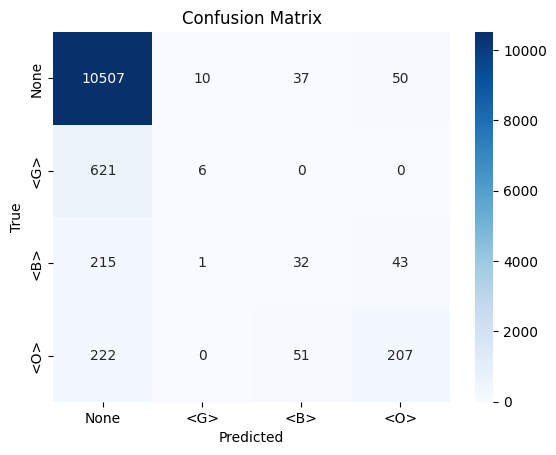

In [14]:
if __name__ == "__main__":
    test_base_dir = "/Users/moanason/Downloads/GBO_audio_eval"  # Update this path to your test data folder.
    model_path = "/Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_w4.pt"
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)
    
    evaluate_model_with_confusion(test_base_dir, model_path, device, batch_size=2)